# Proposed Model — CEDAR Split Evaluation

DenseNet-121 + CBAM (post-block / pre-transition) trained in two steps:

| Step | Method | Epochs |
|---|---|---|
| 1 — Pretraining | TripletLoss (Euclidean, hard-negative mining) | 30 |

Combined total = **100 epochs**, matching the baseline budget exactly.

| | |
|---|---|
| **Dataset** | CEDAR |
| **Split** | 70:15:15 |

**Prerequisite:** run `scripts/prepare_split_ratios.py` to generate split JSONs.

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import seaborn as sns
 
REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
 
from models.feature_extractor                  import DenseNetFeatureExtractor
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss                       import TripletLoss
from utils.model_evaluation                    import (compute_metrics, _plot_det_curve,
                                                        _plot_far_frr, _plot_confusion_matrix,
                                                        _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms, sample_augment_params, preprocess_image
 
 
def seed_everything(seed=42):
    """Seed all random sources for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")
 
 
seed_everything(42)
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
NOTEBOOK_NAME = 'tDCBAM_hindi'
DATASET       = 'bhsig_hindi'
DATASET_NAME  = 'BHSig-Hindi'
 
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)
 
SPLIT_RATIOS = ['70_15_15']
 
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4
 
# ── Triplet Training Hyperparameters ─────────────────────────────────────────
TRAIN_EPOCHS        = 100   # total epochs
TRAIN_PHASE1_EPOCHS = 20    # epochs with backbone frozen (Phase 1)
TRAIN_LR            = 1e-4
TRAIN_MARGIN        = 1.0
TRAIN_WEIGHT_DECAY  = 1e-4
TRAIN_BATCH_SIZE    = 32
 
FEATURE_DIM   = 1024
EMBEDDING_DIM = 1024
 
print(f" > [Config] Epochs: {TRAIN_EPOCHS} (P1 frozen: {TRAIN_PHASE1_EPOCHS})")
print(f" > [Config] LR: {TRAIN_LR} | Margin: {TRAIN_MARGIN} | "
      f"WD: {TRAIN_WEIGHT_DECAY} | Batch: {TRAIN_BATCH_SIZE}")

 > [Config] Epochs: 100 (P1 frozen: 20)
 > [Config] LR: 0.0001 | Margin: 1.0 | WD: 0.0001 | Batch: 32


## Step 3 — Transforms

In [3]:
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)
 
print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")

 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Datasets

Two dataset classes are required by the proposed two-step training procedure:

| Class | Used in | Returns |
|---|---|---|
| `SplitTripletDataset` | Step 1 pretraining | (anchor, positive, negative, dummy_label) |

In [4]:
class SplitTripletDataset(Dataset):
    """
    Triplet dataset for triplet-loss training.
 
    Generates (Anchor, Positive, Negative) triplets with hard negative mining:
        70 % of negatives are skilled forgeries from the same writer (hard).
        30 % are genuine signatures from a randomly chosen other writer (easy).
 
    Triplets are regenerated each epoch via _generate_triplets() to prevent
    the model from memorising fixed pairings across epochs.
 
    Augmentation mode is controlled by the `training` flag:
        training=True  → triplet-level augmentation (proposed pipeline).
                         sample_augment_params() is called ONCE per __getitem__
                         and the same flip/rotation/scale/translation is applied
                         to all three images. This prevents the model from
                         seeing orientation-mismatched anchor-positive pairs.
        training=False → val_transform is applied per-image (no augmentation).
 
    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        val_transform(callable) : Transform used for val/test (no augmentation).
                                  Pass get_transforms(mode='val'). Required.
        training     (bool)     : True for train split, False for val/test.
    """
 
    def __init__(self, user_dict, input_shape=(224, 224),
                 val_transform=None, training=True):
        self.input_shape   = input_shape
        self.val_transform = val_transform
        self.training      = training
 
        self.user_genuine_map  = {}
        self.user_forged_map   = {}
        self.all_genuine_paths = []
 
        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid]  = forg_paths
                self.all_genuine_paths.extend((p, uid) for p in gen_paths)
 
        self.users = list(self.user_genuine_map.keys())
        self._generate_triplets()
        mode_label = "triplet-level aug" if training else "no aug"
        print(f"   TripletDataset: {len(self.triplets)} triplets | "
              f"{len(self.users)} users | {mode_label}")
 
    def _generate_triplets(self):
        """Regenerate all triplets. Call at the end of each epoch."""
        self.triplets = []
        for anchor_path, uid in self.all_genuine_paths:
            positives = [p for p in self.user_genuine_map[uid] if p != anchor_path]
            if not positives:
                continue
            pos_path  = random.choice(positives)
            forgeries = self.user_forged_map.get(uid, [])
            if random.random() < 0.7 and forgeries:
                neg_path = random.choice(forgeries)
            else:
                other_uid = random.choice([u for u in self.users if u != uid])
                neg_path  = random.choice(self.user_genuine_map[other_uid])
            self.triplets.append((anchor_path, pos_path, neg_path))
 
    def __len__(self):
        return len(self.triplets)
 
    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]
 
        if self.training:
            anchor   = self._load_train(a_path)
            positive = self._load_train(p_path)
            negative = self._load_train(n_path)
        else:
            anchor   = self._load_infer(a_path)
            positive = self._load_infer(p_path)
            negative = self._load_infer(n_path)
 
        return anchor, positive, negative, torch.tensor([1], dtype=torch.float32)
 
    def _load_train(self, path):
        img = Image.open(path).convert('RGB')
        return preprocess_image(img, img_size=self.input_shape, augment=True)
 
    def _load_infer(self, path):
        img = Image.open(path).convert('RGB')
        if self.val_transform:
            return self.val_transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)
 
 
class SplitPairDataset(Dataset):
    """
    Pairwise dataset for validation and test evaluation.
 
    Builds (support, query, label) pairs where:
        label = 1  →  both images are genuine (same writer)
        label = 0  →  support is genuine, query is a skilled forgery
 
    For each writer:
        - Genuine pairs  : all C(n_genuine, 2) combinations
        - Forgery pairs  : genuine[i] paired with each forged sample
 
    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        transform    (callable) : Validation transform (no augmentation).
    """
 
    def __init__(self, user_dict, input_shape=(224, 224), transform=None):
        self.input_shape = input_shape
        self.transform   = transform
        self.pairs       = []
 
        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
 
            # Genuine–Genuine pairs (label = 1)
            for i in range(len(gen_paths)):
                for j in range(i + 1, len(gen_paths)):
                    self.pairs.append((gen_paths[i], gen_paths[j], 1))
 
            # Genuine–Forged pairs (label = 0)
            for g_path in gen_paths:
                for f_path in forg_paths:
                    self.pairs.append((g_path, f_path, 0))
 
        print(f"   PairDataset: {len(self.pairs)} pairs "
              f"({sum(1 for _,_,l in self.pairs if l==1)} genuine, "
              f"{sum(1 for _,_,l in self.pairs if l==0)} forged)")
 
    def __len__(self):
        return len(self.pairs)
 
    def __getitem__(self, idx):
        sup_path, qry_path, label = self.pairs[idx]
        sup_img = self._load(sup_path)
        qry_img = self._load(qry_path)
        return sup_img, qry_img, torch.tensor(label, dtype=torch.float32)
 
    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            return self.transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)
 
 
print(" > [Dataset] SplitTripletDataset defined")
print(" > [Dataset] SplitPairDataset defined")

 > [Dataset] SplitTripletDataset defined
 > [Dataset] SplitPairDataset defined


## Step 5 — Data Preview

Visualise preprocessed + augmented training triplets **before** training begins. Each row shows one (Anchor, Positive, Negative) triplet as received by Step 1. Run this cell to verify binarisation, dilation, crop, pad, and normalisation.

 > [Viz] Preview using split '70_15_15'
   TripletDataset: 2688 triplets | 112 users | triplet-level aug


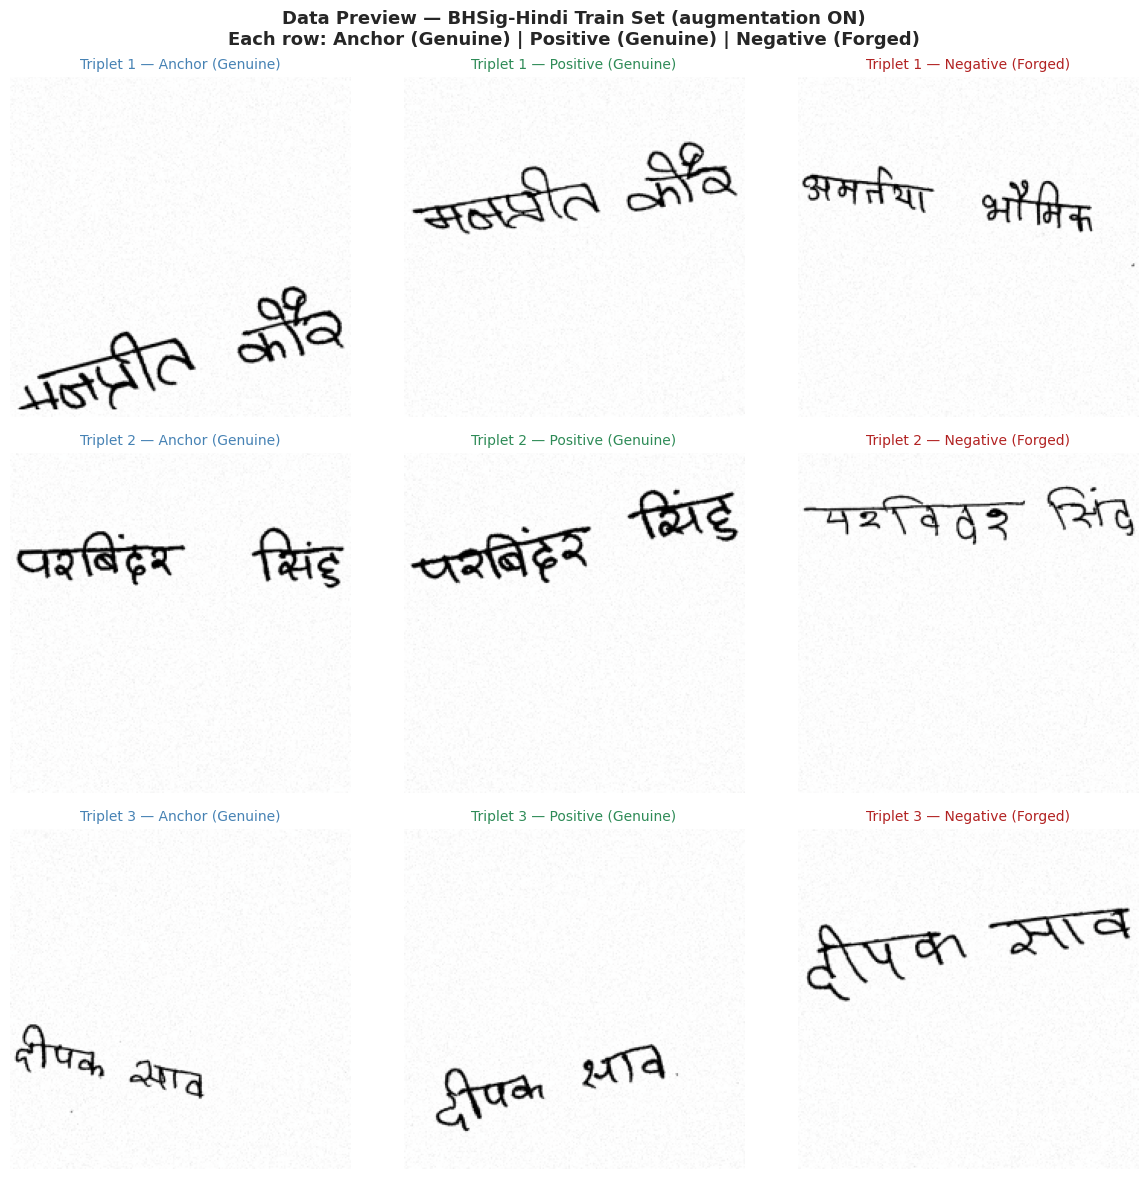

 > [Viz] Displayed 3 augmented triplets


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)          # C,H,W → H,W,C
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)
 
 
_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break
 
if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    _ds     = SplitTripletDataset(
        _prev_data['train'], input_shape=INPUT_SHAPE,
        val_transform=val_transform, training=True
    )
    _loader = DataLoader(_ds, batch_size=4, shuffle=True, num_workers=0)
    _a, _p, _n, _ = next(iter(_loader))
 
    N = min(3, _a.size(0))
    fig, axes = plt.subplots(N, 3, figsize=(12, 4 * N))
    fig.suptitle(
        f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)\n"
        "Each row: Anchor (Genuine) | Positive (Genuine) | Negative (Forged)",
        fontsize=13, fontweight='bold')
 
    if N == 1:
        axes = axes[np.newaxis, :]
 
    for i in range(N):
        for j, (tensor, title, color) in enumerate(zip(
                [_a[i], _p[i], _n[i]],
                ["Anchor (Genuine)", "Positive (Genuine)", "Negative (Forged)"],
                ['steelblue',        'seagreen',           'firebrick'])):
            axes[i, j].imshow(_unnorm(tensor))
            axes[i, j].set_title(f"Triplet {i+1} — {title}",
                                  fontsize=10, color=color)
            axes[i, j].axis('off')
 
    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {N} augmented triplets")
 

## Step 6 — Training Utilities

In [6]:

# ── Backbone freeze / unfreeze ────────────────────────────────────────────────
def freeze_backbone(fe):
    """Freeze all backbone parameters (DenseNet-121 weights)."""
    for p in fe.get_backbone_params():
        p.requires_grad = False
 
 
def unfreeze_backbone(fe):
    """Unfreeze all model parameters for full fine-tuning."""
    for p in fe.parameters():
        p.requires_grad = True
 
 
# ── Distance-based validation ─────────────────────────────────────────────────
def validate(fe, loader, device):
    """
    Evaluates the feature extractor using pairwise Euclidean distance
    on the unit hypersphere.
 
    For each (support, query) pair:
        - Computes SED on L2-normalized embeddings (range [0, 4])
        - Converts to similarity score in [0, 1] (higher = more similar)
        - Passes scores and labels to compute_metrics for EER, AUC, etc.
 
    Args:
        fe     (DenseNetFeatureExtractor): Feature extractor in eval mode.
        loader (DataLoader)              : Pairwise validation/test loader.
        device (torch.device)            : Target device.
 
    Returns:
        dict: Metrics from compute_metrics (eer, auc, accuracy, f1, etc.)
    """
    fe.eval()
    all_scores, all_labels = [], []
 
    with torch.no_grad():
        for sup_imgs, qry_imgs, labels in loader:
            sup_imgs = sup_imgs.to(device)
            qry_imgs = qry_imgs.to(device)
            labels   = labels.to(device)
 
            sup_feat = fe(sup_imgs)   # [B, 1024], L2-normalised
            qry_feat = fe(qry_imgs)   # [B, 1024], L2-normalised
 
            # Squared Euclidean Distance on unit sphere, range [0, 4]
            distances = torch.sum((sup_feat - qry_feat) ** 2, dim=1)
 
            # Convert to similarity: higher score = more similar = more genuine
            scores = 1.0 - (distances / 4.0)   # range [0, 1]
 
            all_scores.extend(scores.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
 
    return compute_metrics(all_labels, all_scores)
 
 
# ── Final evaluation with plots ───────────────────────────────────────────────
def evaluate_model(fe, loader, device, output_dir=None, silent=False):
    """
    Runs validate() and optionally prints results and saves evaluation plots.
 
    Args:
        fe         (DenseNetFeatureExtractor): Feature extractor.
        loader     (DataLoader)              : Test loader.
        device     (torch.device)            : Target device.
        output_dir (str, optional)           : Directory to save plots.
        silent     (bool)                    : Suppress print output.
 
    Returns:
        dict: Metrics dictionary.
    """
    metrics = validate(fe, loader, device)
 
    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',       ':.2%'),
                       ('auc',       ':.4f'),
                       ('threshold', ':.4f'),
                       ('accuracy',  ':.2%'),
                       ('precision', ':.2%'),
                       ('recall',    ':.2%'),
                       ('f1',        ':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)
 
    return metrics
 
 
# ── Complete triplet training (two-phase) ─────────────────────────────────────
def run_training(train_user_dict, val_user_dict, test_user_dict,
                 device, checkpoint_path,
                 epochs, phase1_epochs, lr,
                 margin, weight_decay, batch_size,
                 output_dir=None):
    """
    Complete two-phase triplet training loop.
 
    Phase 1 (epochs 1 → phase1_epochs):
        Backbone frozen. Only CBAM + projection head are trained.
        Optimizer: AdamW on head params only, LR = lr.
        No LR scheduler (too early to reduce LR meaningfully).
 
    Phase 2 (epochs phase1_epochs+1 → epochs):
        Backbone unfrozen. Differential learning rates applied:
            Backbone LR = lr × 0.1
            Head LR     = lr
        Scheduler: ReduceLROnPlateau on validation EER.
 
    Validation runs every VAL_EVERY epochs and always on the final epoch.
    Checkpoint saved on best validation EER (not best loss).
    Triplets regenerated at the end of every epoch to prevent memorisation.
 
    Args:
        train_user_dict (dict)        : {uid: {'genuine': [...], 'forged': [...]}}
        val_user_dict   (dict)        : Same structure, validation writers.
        test_user_dict  (dict)        : Same structure, test writers.
        device          (torch.device): Target device.
        checkpoint_path (str)         : Path to save best model checkpoint.
        epochs          (int)         : Total training epochs (e.g. 100).
        phase1_epochs   (int)         : Epochs to keep backbone frozen (e.g. 20).
        lr              (float)       : Base learning rate (e.g. 1e-4).
        margin          (float)       : Triplet loss margin (e.g. 1.0).
        weight_decay    (float)       : AdamW weight decay (e.g. 1e-4).
        batch_size      (int)         : Training batch size (e.g. 32).
        output_dir      (str)         : Directory for final test evaluation plots.
 
    Returns:
        dict: Final test metrics.
    """
    VAL_EVERY = 3   # validate every N epochs
 
    print(f"\n   {'─'*60}")
    print(f"   TRIPLET TRAINING  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR: {lr}  |  Margin: {margin}  |  "
          f"WD: {weight_decay}  |  Batch: {batch_size}")
    print(f"   {'─'*60}")
 
    seed_everything(42)
    t0 = time.time()
 
    # ── Datasets ──────────────────────────────────────────────────────────────
    train_dataset = SplitTripletDataset(
        train_user_dict,
        input_shape=INPUT_SHAPE,
        val_transform=val_transform,
        training=True
    )
    val_dataset = SplitPairDataset(
        val_user_dict,
        input_shape=INPUT_SHAPE,
        transform=val_transform
    )
    test_dataset = SplitPairDataset(
        test_user_dict,
        input_shape=INPUT_SHAPE,
        transform=val_transform
    )
 
    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
        persistent_workers=(NUM_WORKERS > 0)
    )
 
    # ── Model + Loss ──────────────────────────────────────────────────────────
    model     = tDCBAM(backbone_name='densenet121',
                       output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin, mode='euclidean')
    scaler    = torch.amp.GradScaler('cuda')
 
    # ── Phase 1 Setup ─────────────────────────────────────────────────────────
    freeze_backbone(model.feature_extractor)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {n_train:,} / {n_total:,} params trainable (backbone frozen)")
 
    optimizer    = optim.AdamW(model.get_head_params(), lr=lr, weight_decay=weight_decay)
    scheduler    = None
    best_eer     = float('inf')
    best_metrics = {}
 
    # ── Training Loop ─────────────────────────────────────────────────────────
    for epoch in range(epochs):
 
        # ── Phase transition at epoch phase1_epochs ───────────────────────────
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: {n_train:,} params trainable (backbone unfrozen)")
 
            optimizer = optim.AdamW([
                {'params': model.get_backbone_params(), 'lr': lr * 0.1},
                {'params': model.get_head_params(),     'lr': lr}
            ], weight_decay=weight_decay)
 
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )
 
        # ── Train one epoch ───────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
 
        for anchor, pos, neg, _ in tqdm(
                train_loader, desc=f"Train E{epoch+1:02d}", leave=False):
 
            anchor = anchor.to(device)
            pos    = pos.to(device)
            neg    = neg.to(device)
 
            optimizer.zero_grad()
 
            with torch.amp.autocast('cuda'):
                loss = criterion(*model(anchor, pos, neg))
 
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()
 
        avg_loss = epoch_loss / len(train_loader)
        phase    = 1 if epoch < phase1_epochs else 2
 
        # ── Periodic validation ───────────────────────────────────────────────
        should_validate = (
            (epoch + 1) % VAL_EVERY == 0 or
            (epoch + 1) == epochs
        )
 
        if should_validate:
            val_metrics = validate(model.feature_extractor, val_loader, device)
            val_eer     = val_metrics['eer']
            val_acc     = val_metrics['accuracy']
 
            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Active: {criterion.last_fraction_active:.1%} | "
                  f"Val EER: {val_eer:.2%} | "
                  f"Val Acc: {val_acc:.2%}")
 
            if scheduler is not None:
                scheduler.step(val_eer)
 
            if val_eer < best_eer:
                best_eer     = val_eer
                best_metrics = val_metrics
                torch.save(model.feature_extractor.state_dict(), checkpoint_path)
                print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")
 
        else:
            print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Active: {criterion.last_fraction_active:.1%} | "
                  f"(skipping val)")
 
        # ── Regenerate triplets each epoch ────────────────────────────────────
        train_dataset._generate_triplets()
 
    # ── Final test evaluation ─────────────────────────────────────────────────
    if os.path.exists(checkpoint_path):
        state = torch.load(checkpoint_path, map_location=device, weights_only=True)
        model.feature_extractor.load_state_dict(state, strict=True)
        print("   Best checkpoint reloaded for final test evaluation")
 
    final_metrics = evaluate_model(
        model.feature_extractor, test_loader, device,
        output_dir=output_dir, silent=False
    )
 
    print(f"\n   Training done | Best Val EER: {best_eer:.2%} | "
          f"Time: {time.time() - t0:.1f}s")
 
    return final_metrics
 
 
print(" > [Utils] All training functions defined")

 > [Utils] All training functions defined


## Step 7 — Run All Splits

In [7]:
all_results = {}
timing_log  = {}
 
for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
 
    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)
 
    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")
    print(f" > [Config] Dataset: {DATASET_NAME} | Split: {split_label}")
    print(f" > [Config] Triplet Training: {TRAIN_EPOCHS} ep "
          f"(P1 frozen: {TRAIN_PHASE1_EPOCHS}) | margin={TRAIN_MARGIN}")
    print(f" > [Config] LR: {TRAIN_LR} | WD: {TRAIN_WEIGHT_DECAY} | "
          f"Checkpoints: {CHECKPOINT_DIR}")
 
    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})")
        continue
 
    with open(split_file) as f:
        split_data = json.load(f)
 
    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']
    print(f"  Writers — Train: {len(train_dict)} | "
          f"Val: {len(val_dict)} | Test: {len(test_dict)}")
 
    # ── Triplet Training ──────────────────────────────────────────────────────
    seed_everything(42)
    checkpoint_path = os.path.join(exp_dir, "best_triplet_model.pth")
    t0_train = time.time()
 
    best_metrics = run_training(
        train_user_dict=train_dict,
        val_user_dict=val_dict,
        test_user_dict=test_dict,
        device=DEVICE,
        checkpoint_path=checkpoint_path,
        epochs=TRAIN_EPOCHS,
        phase1_epochs=TRAIN_PHASE1_EPOCHS,
        lr=TRAIN_LR,
        margin=TRAIN_MARGIN,
        weight_decay=TRAIN_WEIGHT_DECAY,
        batch_size=TRAIN_BATCH_SIZE,
        output_dir=split_eval_dir
    )
    t_train = time.time() - t0_train
 
    # ── Record results ────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':     DATASET_NAME,
        'split':       split_label,
        'train_users': len(train_dict),
        'val_users':   len(val_dict),
        'test_users':  len(test_dict),
        'eer':         float(best_metrics['eer']),
        'accuracy':    float(best_metrics['accuracy']),
        'auc':         float(best_metrics['auc']),
        'precision':   float(best_metrics.get('precision', 0)),
        'recall':      float(best_metrics.get('recall',    0)),
        'f1':          float(best_metrics.get('f1',        0)),
    }
    timing_log[key] = {
        'train_s': round(t_train, 1),
        'total_s': round(t_train, 1)
    }
 
    print(f"  RESULT [{split_label}]: "
          f"EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1', 0):.4f} | "
          f"Time={t_train:.1f}s")
 
print(f"\n{'='*70}\nALL EXPERIMENTS COMPLETE\n{'='*70}")


  BHSig-Hindi  —  70:15:15  Split
 > [Config] Dataset: BHSig-Hindi | Split: 70:15:15
 > [Config] Triplet Training: 100 ep (P1 frozen: 20) | margin=1.0
 > [Config] LR: 0.0001 | WD: 0.0001 | Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits
  Writers — Train: 112 | Val: 24 | Test: 24
 > [Seed] 42

   ────────────────────────────────────────────────────────────
   TRIPLET TRAINING  |  100 epochs  (P1 frozen: 20)
   LR: 0.0001  |  Margin: 1.0  |  WD: 0.0001  |  Batch: 32
   ────────────────────────────────────────────────────────────
 > [Seed] 42
   TripletDataset: 2688 triplets | 112 users | triplet-level aug
   PairDataset: 23904 pairs (6624 genuine, 17280 forged)
   PairDataset: 23904 pairs (6624 genuine, 17280 forged)
   Phase 1: 1,658,248 / 8,612,104 params trainable (backbone frozen)


Train E01:   0%|          | 0/84 [00:00<?, ?it/s]

   [P1] Epoch 01/100 | Loss: 0.8291 | Active: 96.9% | (skipping val)


Train E02:   0%|          | 0/84 [00:00<?, ?it/s]

   [P1] Epoch 02/100 | Loss: 0.7657 | Active: 87.5% | (skipping val)


...

   [P2] Epoch 98/100 | Loss: 0.1289 | Active: 3.1% | (skipping val)


Train E99:   0%|          | 0/84 [00:00<?, ?it/s]

   [P2] Epoch 99/100 | Loss: 0.0930 | Active: 3.1% | Val EER: 25.05% | Val Acc: 74.95%


Train E100:   0%|          | 0/84 [00:00<?, ?it/s]

   [P2] Epoch 100/100 | Loss: 0.1082 | Active: 0.0% | Val EER: 25.09% | Val Acc: 74.91%
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 26.79%
  AUC          : 0.8083
  THRESHOLD    : 0.7838
  ACCURACY     : 73.21%
  PRECISION    : 51.16%
  RECALL       : 73.20%
  F1           : 60.22%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_hindi/tDCBAM_hindi_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_hindi/tDCBAM_hindi_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_hindi/tDCBAM_hindi_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_hindi/tDCBAM_hindi_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/tDCBAM_hindi/tDCBAM_hindi_70-15-15/far_frr.png

 

## Step 8 — Summary Table

In [8]:
W = 84
print(f"\n{'='*W}")
print(f"{'PROPOSED MODEL  —  ' + DATASET_NAME:^{W}}")
print(f"{'DenseNet-121 + CBAM + Triplet Loss':^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}  "
      f"{'Time(s)':>8}")
print(f"{'-'*W}")
for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}  "
          f"{str(t.get('total_s', '—')):>8}")
print(f"{'='*W}")
 
results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved → {results_path}")


                           PROPOSED MODEL  —  BHSig-Hindi                           
                         DenseNet-121 + CBAM + Triplet Loss                         
Split         Train    Val   Test       EER  Accuracy      AUC       F1   Time(s)
------------------------------------------------------------------------------------
70:15:15        112     24     24    0.2679    0.7321   0.8083   0.6022    2788.1

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_hindi_results.json


## Step 8 — Embedding Space Visualization (t-SNE)


  Step 10 — t-SNE Visualization

 > Preparing data for t-SNE...
   PairDataset: 23904 pairs (6624 genuine, 17280 forged)
 > Loading Best Feature Extractor...
 > Extracting features for t-SNE visualization...
 > Running t-SNE dimensionality reduction on 960 signatures...


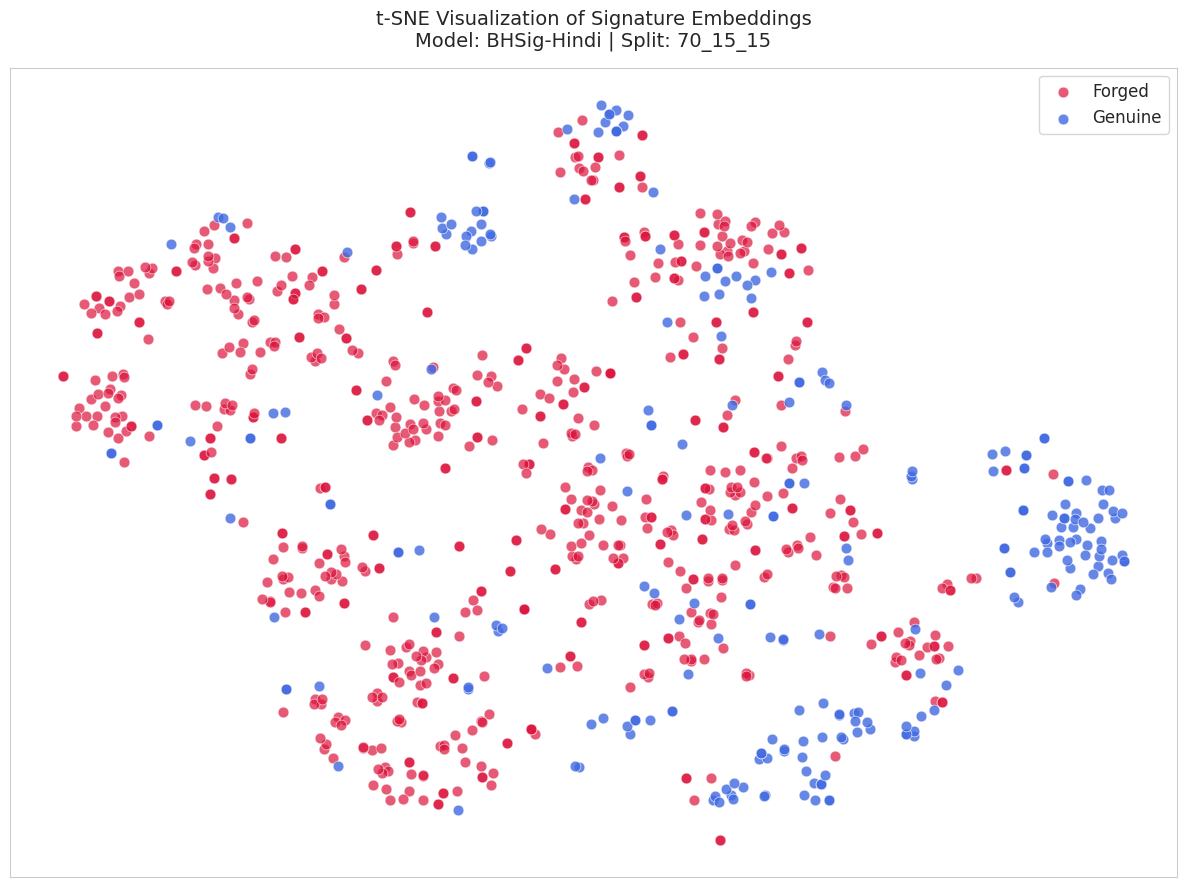

 > t-SNE plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_hindi_tsne.png


In [9]:
def visualize_embedding_space(feature_extractor, dataloader, device, num_batches=15):
    """
    Extracts 1024D embeddings from the DenseNet Feature Extractor and 
    compresses them to 2D using t-SNE to visualize cluster separation.
    """
    feature_extractor.eval()
    all_embeddings = []
    all_labels = []   # 1.0 for Genuine, 0.0 for Forged
    
    print(" > Extracting features for t-SNE visualization...")
    with torch.no_grad():
        for i, (sup_imgs, qry_imgs, labels) in enumerate(dataloader):
            if i >= num_batches: 
                break
                
            # In SplitPairDataset:
            # label = 1 -> query image is a genuine signature
            # label = 0 -> query image is a forged signature
            qry_imgs = qry_imgs.to(device)
            labels = labels.cpu().numpy()
            
            # Extract 1024D features from the backbone
            features = feature_extractor(qry_imgs).cpu().numpy()
            
            all_embeddings.append(features)
            all_labels.append(labels)

    # Concatenate all collected data
    embeddings_np = np.vstack(all_embeddings)
    labels_np = np.concatenate(all_labels)

    print(f" > Running t-SNE dimensionality reduction on {embeddings_np.shape[0]} signatures...")
    
    # Compress 1024D -> 2D
    # Perplexity usually works best between 30 and 50 depending on batch size
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # Plotting
    plt.figure(figsize=(12, 9))
    
    # Plot Forgeries (Red) first so they sit in the background if overlapped
    plt.scatter(embeddings_2d[labels_np == 0, 0], embeddings_2d[labels_np == 0, 1], 
                c='crimson', label='Forged', alpha=0.7, edgecolors='white', s=60, linewidth=0.5)
    
    # Plot Genuine (Blue) on top
    plt.scatter(embeddings_2d[labels_np == 1, 0], embeddings_2d[labels_np == 1, 1], 
                c='royalblue', label='Genuine', alpha=0.8, edgecolors='white', s=60, linewidth=0.5)

    # SPLIT_RATIOS and DATASET_NAME are pulled from your Step 2 Config
    plt.title(f't-SNE Visualization of Signature Embeddings\nModel: {DATASET_NAME} | Split: {SPLIT_RATIOS[-1]}', fontsize=14, pad=15)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Remove axis ticks for a cleaner plot
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    
    # Save the plot alongside the other evaluation charts
    tsne_plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_tsne.png')
    plt.savefig(tsne_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" > t-SNE plot saved → {tsne_plot_path}")

# ── Execution Block ───────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print(f"  Step 10 — t-SNE Visualization")
print(f"{'='*70}")

# 1. Re-initialize the test dataloader using the last processed split data
# (test_dict is already in memory from Step 7)
print("\n > Preparing data for t-SNE...")
tsne_test_set = SplitPairDataset(
    test_dict, 
    input_shape=INPUT_SHAPE, 
    transform=val_transform
)

# Note: shuffle=True ensures we get a diverse mix of genuine/forged signatures 
# from different writers, rather than plotting just one writer's sequential data.
tsne_test_loader = DataLoader(tsne_test_set, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)

# 2. Load the absolute best Feature Extractor from the checkpoint
print(" > Loading Best Feature Extractor...")
tsne_model = tDCBAM(backbone_name='densenet121', output_dim=FEATURE_DIM, pretrained=False).to(DEVICE)

# 'exp_dir' is already defined in your Step 7 loop
best_ckpt_path = os.path.join(exp_dir, "best_triplet_model.pth")

if os.path.exists(best_ckpt_path):
    # In Step 6, you saved model.feature_extractor.state_dict(). 
    # We load it directly into the feature_extractor module.
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
    tsne_model.feature_extractor.load_state_dict(ckpt, strict=True)
    
    # 3. Generate the visualization
    visualize_embedding_space(tsne_model.feature_extractor, tsne_test_loader, DEVICE, num_batches=15)
else:
    print(f"ERROR: Could not find checkpoint at {best_ckpt_path}")

## Step 10 — Results Chart

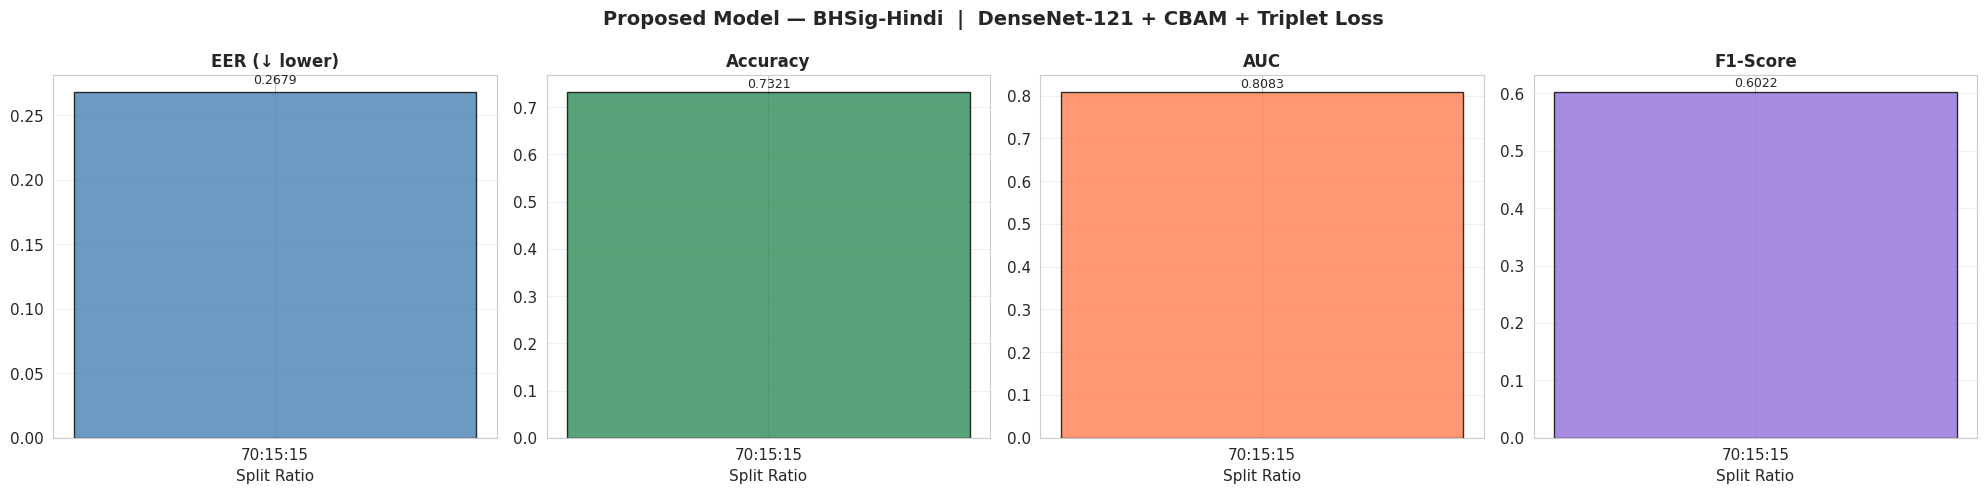

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_bhsig_hindi_comparison.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f'Proposed Model — {DATASET_NAME}  |  DenseNet-121 + CBAM + Triplet Loss',
    fontsize=14, fontweight='bold'
)
 
for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):
 
    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [
        all_results.get(f"{DATASET_NAME} ({r.replace('_', ':')})", {}).get(metric, 0)
        for r in SPLIT_RATIOS
    ]
 
    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")